In [66]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import pandas as pd 
import numpy as numpy 
%matplotlib inline 

In [67]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [68]:
X

array([[ 8.80588484, -1.22571682],
       [ 5.77437366,  3.72283249],
       [ 9.04534243,  0.405403  ],
       ...,
       [ 4.30371357,  6.74346567],
       [ 4.01993903,  4.87816535],
       [ 9.07716805, -0.47852249]], shape=(1000, 2))

In [69]:
y

array([0, 1, 0, 2, 1, 2, 2, 2, 0, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 0, 0,
       1, 0, 1, 1, 2, 2, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 1, 0, 2, 0,
       2, 0, 1, 0, 2, 2, 2, 1, 1, 1, 0, 0, 2, 0, 0, 0, 2, 2, 2, 0, 2, 0,
       2, 1, 2, 0, 0, 1, 1, 2, 2, 1, 1, 1, 2, 0, 0, 1, 2, 0, 1, 2, 0, 0,
       2, 1, 2, 1, 2, 0, 2, 0, 0, 0, 2, 2, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       2, 0, 1, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 0, 2, 2, 2, 2, 1, 0, 2, 0,
       1, 0, 0, 0, 2, 0, 0, 0, 1, 1, 2, 2, 2, 1, 0, 2, 1, 1, 1, 1, 2, 2,
       1, 0, 0, 1, 1, 0, 2, 1, 0, 2, 1, 0, 0, 2, 2, 2, 1, 2, 0, 0, 2, 2,
       2, 2, 2, 1, 2, 0, 1, 2, 2, 2, 2, 0, 2, 0, 2, 0, 1, 2, 0, 0, 1, 0,
       0, 1, 2, 1, 1, 1, 1, 1, 2, 0, 1, 0, 2, 1, 2, 1, 1, 2, 0, 0, 1, 2,
       1, 2, 2, 2, 2, 1, 1, 2, 1, 0, 1, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       2, 0, 2, 0, 1, 1, 0, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 2, 0, 2, 2,
       1, 2, 0, 1, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 0, 1, 1, 2, 0, 1, 1,
       2, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1, 2, 1, 0,

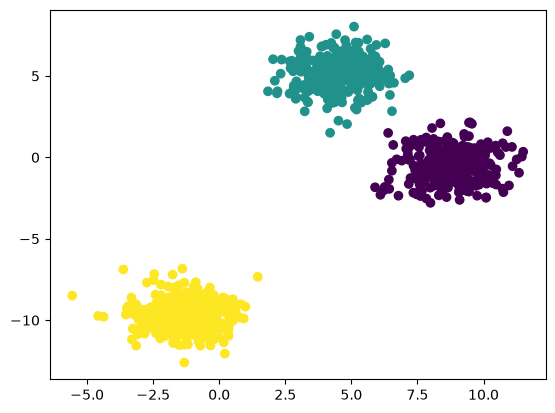

In [70]:
plt.scatter(X[:,0],X[:,1],c=y)

In [71]:
#standardization --features scaling technique
from sklearn.preprocessing import StandardScaler
scaler  = StandardScaler()

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [74]:
X_train_Scaled = scaler.fit_transform(X_train)

In [75]:
X_test_Scaled = scaler.transform(X_test)

In [76]:
from sklearn.cluster import KMeans

In [77]:
##elbow method 
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_Scaled)
    wcss.append(kmeans.inertia_)
    

In [78]:
wcss

[1339.9999999999995,
 251.20480999310195,
 53.54742570147948,
 43.492405766815544,
 36.21255952548836,
 33.64113073685242,
 26.289643962070073,
 24.47667280797084,
 21.57501343315998,
 19.866955963907998]

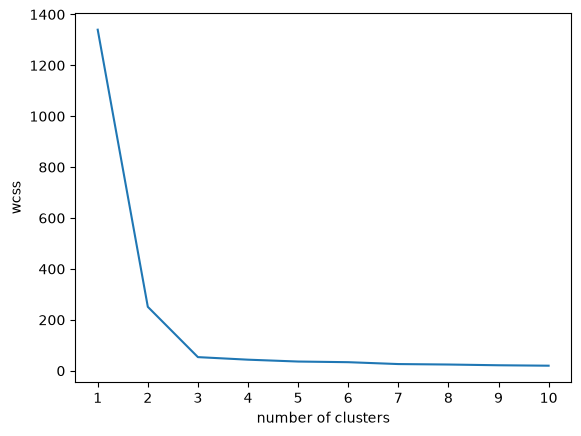

In [79]:
#plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()

In [80]:
kmeans = KMeans(n_clusters=3,init='k-means++')

In [81]:
kmeans.fit_predict(X_train_Scaled)

array([0, 1, 1, 1, 0, 1, 1, 2, 1, 0, 0, 1, 0, 1, 2, 2, 2, 2, 1, 0, 0, 2,
       0, 0, 0, 0, 0, 2, 1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 1, 1, 1, 2, 0,
       1, 1, 1, 1, 1, 1, 0, 2, 1, 0, 2, 0, 1, 2, 2, 2, 1, 0, 2, 0, 1, 1,
       2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 0, 1, 1,
       0, 2, 2, 1, 2, 0, 2, 2, 0, 1, 2, 0, 2, 2, 1, 0, 2, 1, 2, 1, 2, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 2, 1, 1, 0, 1, 0, 1, 2, 2, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2, 0, 1, 1, 2, 0,
       2, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 2, 2, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 2, 1, 0, 1, 1, 0, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       1, 0, 1, 1, 0, 2, 0, 0, 1, 2, 2, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       2, 1, 0, 0, 2, 2, 0, 0, 2, 1, 0, 0, 1, 2, 1, 2, 2, 2, 0, 0, 2, 1,
       2, 1, 1, 1, 1, 2, 0, 2, 1, 1, 0, 2, 1, 2, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 2, 0, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 2, 2, 1, 0, 1, 1, 1, 0,
       0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 2, 1, 2,

In [82]:
y_pred = kmeans.predict(X_test_Scaled)
y_pred

array([0, 2, 2, 1, 1, 0, 0, 2, 0, 1, 1, 2, 0, 0, 0, 0, 2, 1, 0, 2, 2, 1,
       2, 1, 1, 0, 2, 2, 0, 1, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2,
       2, 2, 0, 2, 2, 2, 1, 2, 0, 1, 0, 2, 0, 1, 1, 2, 0, 0, 2, 0, 0, 2,
       1, 1, 0, 2, 0, 2, 2, 1, 0, 1, 2, 1, 1, 0, 2, 1, 2, 2, 1, 0, 2, 1,
       2, 0, 2, 2, 1, 2, 1, 1, 1, 1, 0, 2, 2, 0, 2, 0, 2, 2, 2, 0, 1, 1,
       1, 2, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 2, 1, 0, 2, 1, 0, 0, 2,
       1, 2, 2, 0, 2, 1, 2, 2, 1, 2, 2, 2, 2, 0, 2, 1, 2, 0, 2, 2, 2, 0,
       2, 1, 0, 1, 1, 0, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 1,
       2, 0, 0, 2, 0, 1, 1, 0, 1, 0, 1, 2, 0, 2, 0, 2, 1, 2, 2, 1, 1, 2,
       0, 1, 2, 1, 1, 1, 0, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 2, 1, 1, 0, 0,
       2, 2, 2, 1, 2, 0, 0, 0, 2, 0, 1, 1, 2, 2, 0, 2, 1, 2, 2, 2, 1, 2,
       2, 2, 1, 0, 0, 2, 2, 1, 1, 1, 0, 0, 1, 0, 1, 0, 2, 1, 0, 2, 0, 0,
       1, 2, 0, 0, 2, 2, 1, 0, 0, 2, 1, 1, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2,
       1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 2, 0, 1, 0, 0,

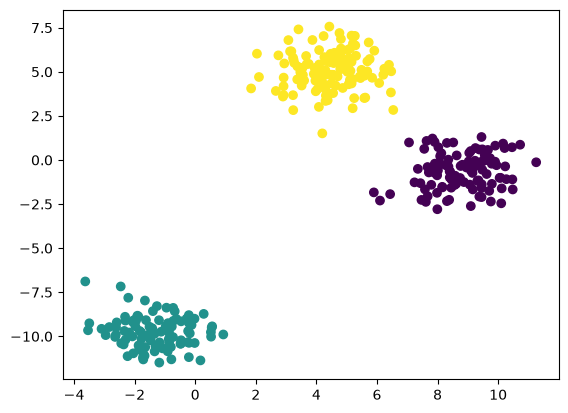

In [83]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

##validating the k value 
##kneeloactor
##silhoutee scoring

In [85]:
##kneelocator
!pip install kneed

In [86]:
from kneed import KneeLocator

In [87]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [88]:
kl.elbow

np.int64(3)

In [90]:
##silhouette score
from sklearn.metrics import silhouette_score

In [93]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_Scaled)
    score=silhouette_score(X_train_Scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [94]:
silhouette_coefficients

[0.7516554806010699,
 0.7867280682734801,
 0.665725150117315,
 0.5098841696867784,
 0.5267965269316799,
 0.36223937160069947,
 0.3487963652742351,
 0.31632115045656334,
 0.33858550980722585]

In [ ]:
#plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()